# (26) Transl Kyoto: local dyna

host = ```mach```, device = ```cuda:3```

**Motivation**:  <br>

- `speed` = 1.0 (anneal = 0.0)
- `crop_size` = 44
- $T_\text{train} = 32$
- $T_\text{tbptt} = 32$

mid lr

In [1]:
# HIDE CODE


project_name = '_TemporalSC'


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, project_name))
from figures.convergence import plot_convergence
from main.config_defaults import default_configs
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 3
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:3  ———  host: mach

## Make a model

In [3]:
model_type = 'poisson'
cfg_vae, cfg_tr = default_configs('Kyoto-wht+translate', model_type, 'ngd|lin')

cfg_vae['t_train'] = 32
cfg_vae['t_tbptt'] = 32
cfg_vae['kl_beta'] = 1.0

cfg_vae['latent_channels'] = 128
cfg_vae['latent_pixels'] = 10
cfg_vae['latent_stride'] = 4

cfg_vae['fwd_ker_u'] = 3
cfg_vae['fwd_ker_z'] = 5

cfg_vae['feeder_cfg'] = {'iters_per_epoch': 200, 'crop_size': 44, 'max_speed': 1.0}
cfg_vae['clamp_vals'] = {'u': (4.0,), 'du': (4.0,), 'dec': 3.45}

cfg_vae['recon_mode'] = 'mse'
cfg_vae['fit_sigma'] = False
cfg_vae['fit_dt'] = False

cfg_tr['lr'] = 5e-4
cfg_tr['epochs'] = 600
cfg_tr['batch_size'] = 100
# cfg_tr['grad_clip'] = 1_000
cfg_tr['warmup_portion'] = 0.01

In [4]:
model = MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae))
tr = Trainer(model, ConfigTrain(**cfg_tr), device=device)

tr.feeder_trn.n_iters

120000

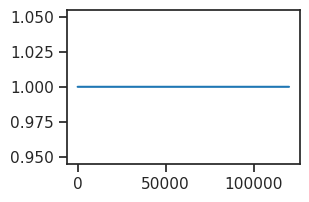

In [5]:
feeder = tr.get_feeder(
    data='trn',
    shuffle=True,
    drop_last=True,
)[0]
plot(feeder.schedule);

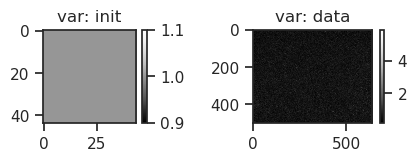

learned inner learning rates (dt):

None

In [6]:
# get var: learned & data
log_sigma = tonp(tr.model.layer.get_dec_log_sigma().squeeze())
var_init = (np.exp(2 * log_sigma)).reshape(tr.model.cfg.input_sz)
var_data = tonp(tr.feeder_trn.x.var(dim=0))

# plot
fig, axes =  create_figure(1, 2, (4.2, 1.5), width_ratios=[1, 1.2])
im = axes[0].imshow(var_init.mean(0), cmap='Greys_r')
plt.colorbar(im, ax=axes[0])
im = axes[1].imshow(var_data.mean(0), cmap='Greys_r')
plt.colorbar(im, ax=axes[1])

axes[0].set_title('var: init')
axes[1].set_title('var: data')

plt.show()

# print dt
try:
    lr_inner = tuple(dt.exp() for dt in tr.model.layer.log_dt)
except TypeError:
    lr_inner = None
print(f"learned inner learning rates (dt):\n\n{lr_inner}\n")

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    IPVAE    |  565.5 K   |
|     ———     |    ———     |
|    layer    |  565.5 K   |
+-------------+------------+

poisson_Kyoto-wht+translate_t-(32,32)_b-1_kms-(128,10,4)_fwd-(3,5)_<ngd|lin>
b100-ep600-lr(0.0005)_temp(0.05)_gr(200)_(2025_08_28,10:51)

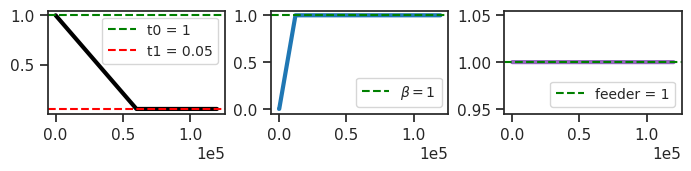

In [7]:
model.print()
tr.print()
tr.show_schedules()

In [8]:
model.layer.n_exp

tensor([10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
        10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10],
       device='cuda:3', dtype=torch.int32)

In [9]:
print(f"\n\n{tr.model.layer}\n\n{tr.model.layer.dec}\n")

PoissonLayer(latent_sz=(128, 10, 10), input_sz=(1, 44, 44), temp=1)

ConvDictionary(in_channels=128, out_channels=1, kernel_size=8, stride=4)

In [10]:
print_num_params(tr.model.layer)

+--------------+------------+
| Module Name  | Num Params |
+--------------+------------+
| PoissonLayer |  565.5 K   |
|     ———      |    ———     |
|     dec      |   8.2 K    |
|   fwd_z.0    |  409.6 K   |
|   fwd_u.0    |  147.5 K   |
|    u_init    |    128     |
+--------------+------------+

In [11]:
print(f"\n\n{vars(tr.model.cfg)}\n\n{vars(tr.cfg)}\n")

{'prior_log_dist': 'uniform', 'clamp_prior': -4, 't_train': 32, 't_tbptt': 32, 'kl_beta': 1.0, 'latent_channels': 
128, 'latent_pixels': 10, 'latent_stride': 4, 'fwd_ker_u': 3, 'fwd_ker_z': 5, 'enc_type': 'ngd', 'dec_type': 'lin',
'recon_mode': 'mse', 'dataset': 'Kyoto-wht+translate', 'dataset_name': 'Kyoto-wht', 'feeder': 'translate', 
'feeder_cfg': {'iters_per_epoch': 200, 'crop_size': 44, 'max_speed': 1.0, 'blur_sigma': 0.5, 'anneal_portion': 0.0,
'shift_rescale': True, 'snap_to_pixel': False, 'mode': 'bilinear'}, 'input_sz': (1, 44, 44), 'latent_sz': (128, 10,
10), 'init_dist': 'normal', 'init_scale': 0.0001, 'clamp_vals': {'u': (4.0,), 'du': (4.0,), 'dec': 3.45}, 
'stochastic': True, 'optim_sigma': False, 'fit_sigma': False, 'fit_prior': True, 'fit_dt': False, 'seed': 0, 
'track_stats': False, 'base_dir': '/home/hadi/Projects/TemporalSC', 'data_dir': '/home/hadi/Datasets', 'runs_dir': 
'/home/hadi/Projects/TemporalSC/runs/poisson_Kyoto-wht+translate_t-(32,32)_b-1_kms-(128,10,4)_fwd-(3,5)_<ngd|lin>',
'mods_dir': 
'/home/hadi/Projects/TemporalSC/models/poisson_Kyoto-wht+translate_t-(32,32)_b-1_kms-(128,10,4)_fwd-(3,5)_<ngd|lin>
', 'results_dir': '/home/hadi/Projects/TemporalSC/results'}

{'lr': 0.0005, 'epochs': 600, 'batch_size': 100, 'dataset_kws': None, 'warm_restart': 0, 'warmup_portion': 0.01, 
'optimizer': 'adamax_fast', 'optimizer_kws': {'weight_decay': 0.001, 'betas': (0.9, 0.999), 'eps': 1e-08}, 
'scheduler_type': 'cosine', 'scheduler_kws': {'T_max': 594.0, 'eta_min': 1e-06}, 'ema_rate': None, 'grad_clip': 
200, 'chkpt_freq': 50, 'eval_freq': 20, 'log_freq': 10, 'kl_beta_min': 0.0001, 'kl_const_portion': 0.001, 
'kl_anneal_portion': 0.1, 'temp_anneal_portion': 0.5, 'temp_anneal_type': 'lin', 'temp_start': 1.0, 'temp_stop': 
0.05}

In [12]:
comment = '_'.join([
    f"fwd:u{tr.model.cfg.fwd_ker_u}+z{tr.model.cfg.fwd_ker_z}",
    f"fit:{'dt' if tr.model.cfg.fit_dt else ''}+{'sig' if tr.model.cfg.fit_sigma else ''}",
    'Speed=1.0',
    'Anneal=0.0',
])
print(comment)

fwd:u3+z5_fit:+_Speed=1.0_Anneal=0.0

In [13]:
tr.train(comment=comment)

wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.


Warning: Could not save code info: Reference at 'refs/heads/main' does not exist

Warning: Could not save notebook info: Can't identify the notebook path.

epoch # 87, avg loss: 16347.557:  14%|▍  | 87/600 [2:46:56<16:24:20, 115.13s/it]


OutOfMemoryError: CUDA out of memory. Tried to allocate 376.00 MiB. GPU 3 has a total capacity of 47.41 GiB of which 293.12 MiB is free. Including non-PyTorch memory, this process has 47.10 GiB memory in use. Of the allocated memory 46.21 GiB is allocated by PyTorch, and 415.43 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
%%time

results = tr.analysis('vld', t_total=1000, n_data_batches=5)
_ = plot_convergence(results=results, color='C0')

In [ ]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
tr.model.show(order=np.argsort(u0));

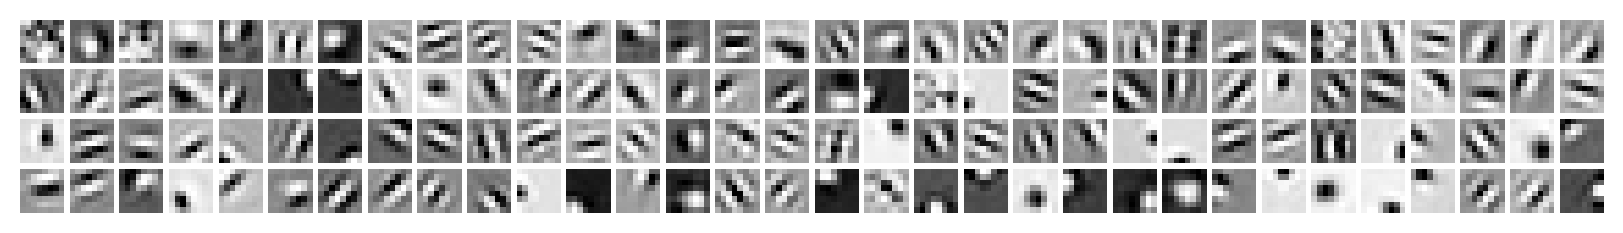

In [17]:
output = tr.xtract_ftr(
    data='vld',
    t_total=32,
    save_freq=1,
    data_batch_sz=50,
    n_data_batches=1,
    return_recon=True,
    verbose=False,
)

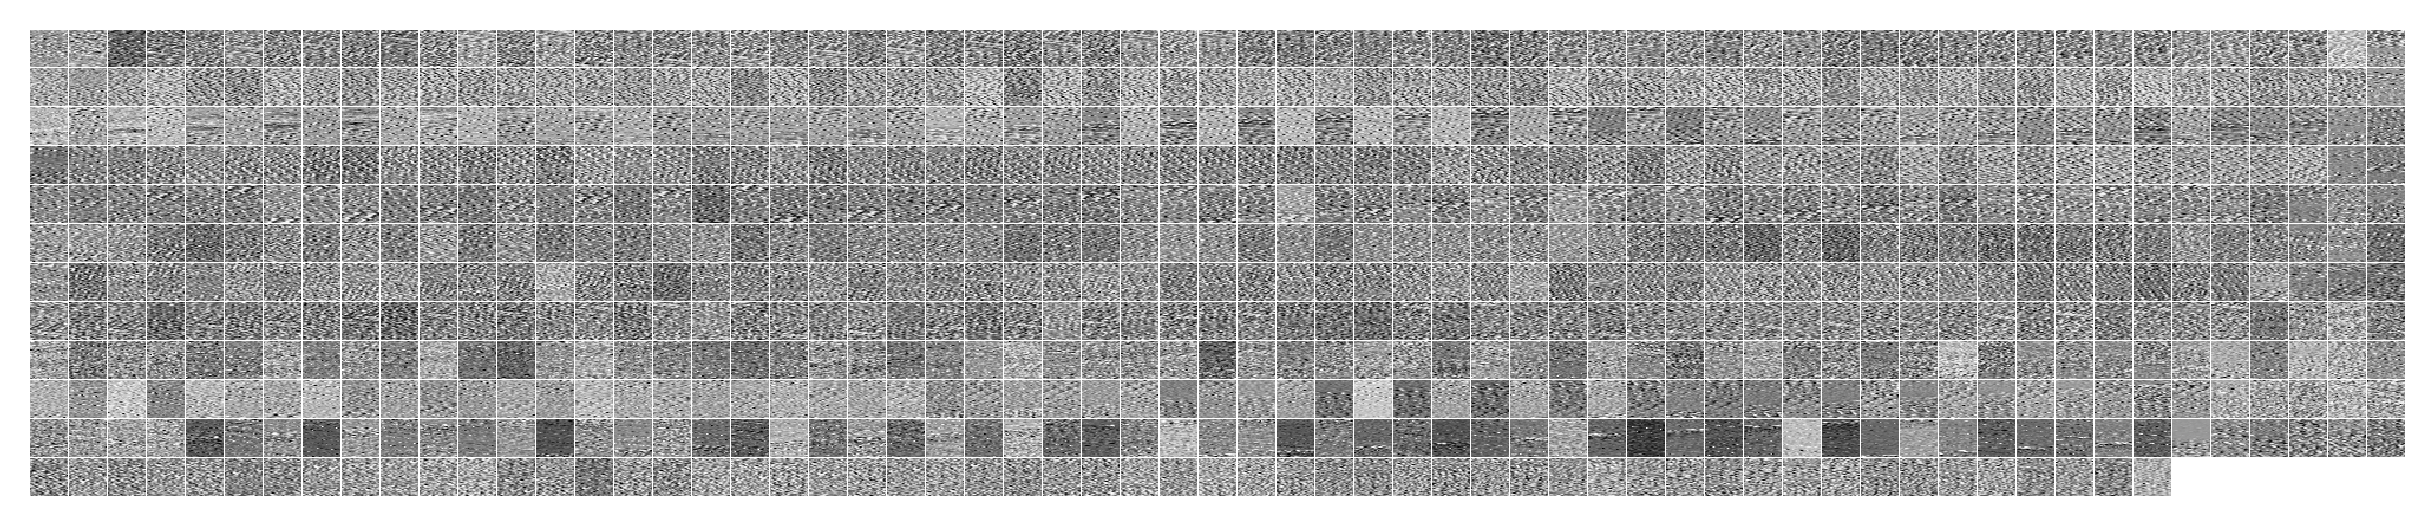

In [18]:
num = 12
x2p = output['recon'][:num].reshape(-1, 32, 32)
_ = plot_weights(x2p, method='min-max', nrows=num, dpi=300)